In [1]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
import psutil

from time import time
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from collections import OrderedDict

# Load custom modules
from commoncupy.functions import *
from commoncupy.layers import *
from commoncupy.optimizer import *
from commoncupy.util import *

# 한글 폰트 및 마이너스 기호 표시 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

CuPy not available or GPU not found: <<No module named 'cupy'>>. Falling back to NumPy for core operations.
CuPy not available or GPU not found: <<No module named 'cupy'>>. Falling back to NumPy for core operations.
CuPy not available or GPU not found: <<No module named 'cupy'>>. Falling back to NumPy for core operations.
CuPy not available or GPU not found: <<No module named 'cupy'>>. Falling back to NumPy for core operations.


In [2]:
try:
    import cupy as cp
    cp.cuda.Device(0).use()
    print("CuPy is available and using GPU 0.")
    xp = cp # 연산에 사용할 주 라이브러리 (CuPy)
except Exception as e:
    import numpy as np
    print(f"CuPy not available or GPU not found: <<{e}>>. Falling back to NumPy for core operations.")
    xp = np # CuPy 사용 불가 시 NumPy로 대체 (오류 방지 및 CPU 실행용)
    # 이 경우, 아래 정의되는 함수/클래스에서 xp를 사용하므로 NumPy로 동작하게 됩니다.

seed = 42 # 원하는 시드 값으로 설정
np.random.seed(seed)
try:
    if xp == cp:
        cp.random.seed(seed)
except Exception as e:
    print(f"CuPy not available or GPU not found: {e}. Set Numpy random seed.")
    cp = -1
    np.random.seed(seed)
    
# numpy 멀티스레드 설정 - 최대 CPU 코어 수에 맞춰서 설정
# 에러나는경우 PC 사양에 따라 수동 조절
cpu_count = str(psutil.cpu_count(logical=False))
os.environ["OMP_NUM_THREADS"] = cpu_count
os.environ["OPENBLAS_NUM_THREADS"] = cpu_count
os.environ["MKL_NUM_THREADS"] = cpu_count
os.environ["VECLIB_MAXIMUM_THREADS"] = cpu_count
os.environ["NUMEXPR_NUM_THREADS"] = cpu_count
ram_size = psutil.virtual_memory().total / (1024 ** 3) # 최대 램용량 저장
print(f"CPU 코어 수: {cpu_count}, RAM 크기: {ram_size:.2f}GB")
print(f"Array operations will use: {'CuPy (GPU)' if xp == cp else 'NumPy (CPU)'}")

CuPy not available or GPU not found: <<No module named 'cupy'>>. Falling back to NumPy for core operations.
CuPy not available or GPU not found: name 'cp' is not defined. Set Numpy random seed.
CPU 코어 수: 4, RAM 크기: 15.84GB
Array operations will use: NumPy (CPU)


In [3]:
class ReduceLROnPlateau:
    def __init__(self, optimizer, mode='min', factor=0.1, patience=10, 
                 verbose=False, min_lr=0, eps=1e-8):
        if factor >= 1.0:
            raise ValueError('Factor should be < 1.0.')
        self.optimizer = optimizer
        self.mode = mode
        self.factor = factor
        self.patience = patience
        self.verbose = verbose
        self.min_lr = min_lr # 최소 학습률 (리스트 또는 단일 값)
        self.eps = eps

        self.best = None
        self.num_bad_epochs = 0
        self.last_epoch = 0 # PyTorch의 ReduceLROnPlateau와 유사하게 last_epoch 관리

        self._reset()

    def _reset(self):
        """Resets num_bad_epochs counter and cooldown counter."""
        self.best = float('inf') if self.mode == 'min' else float('-inf')
        self.num_bad_epochs = 0

    def step(self, metrics, epoch=None):
        current_epoch = epoch if epoch is not None else self.last_epoch + 1
        self.last_epoch = current_epoch

        if self.is_better(metrics, self.best):
            self.best = metrics
            self.num_bad_epochs = 0
        else:
            self.num_bad_epochs += 1

        if self.num_bad_epochs > self.patience:
            self._reduce_lr(current_epoch)
            self.num_bad_epochs = 0 # 학습률 감소 후 bad_epochs 초기화

    def _reduce_lr(self, epoch):
        for i, param_group in enumerate(self.optimizer.param_groups if hasattr(self.optimizer, 'param_groups') else [{'lr': self.optimizer.lr}]):
            old_lr = float(param_group['lr'] if hasattr(self.optimizer, 'param_groups') else self.optimizer.lr)
            new_lr = max(old_lr * self.factor, self.min_lr[i] if isinstance(self.min_lr, list) else self.min_lr)
            
            if old_lr - new_lr > self.eps: # 의미 있는 변화가 있을 때만 업데이트
                if hasattr(self.optimizer, 'param_groups'):
                     param_group['lr'] = new_lr
                else: # SGD, Adam 등 직접 lr 속성을 가지는 경우
                     self.optimizer.lr = new_lr
                if self.verbose:
                    print(f'Epoch {epoch}: reducing learning rate of group {i} to {new_lr:.4e}.')

    def is_better(self, a, best):
        if self.mode == 'min':
            return a < best
        else: # mode == 'max'
            return a > best

    # CustomTrainer에서 optimizer의 lr을 직접 참조하므로, param_groups가 없는 옵티마이저를 위해 추가
    # 이 부분은 CustomTrainer가 optimizer.lr을 직접 사용하지 않고, 
    # optimizer.get_lr() 같은 메서드를 사용하도록 변경하면 더 일반적일 수 있습니다.
    # 현재 CustomOptimizer들은 lr 속성을 직접 가지고 있으므로, 
    # CustomTrainer에서 optimizer.lr을 직접 읽는 것은 문제가 없습니다.
    # 다만, PyTorch의 Optimizer처럼 param_groups를 사용하는 경우를 대비하여 위와 같이 분기 처리했습니다.
    # 현재 구현된 SGD, Adam 등은 param_groups가 없으므로, 
    # CustomTrainer에서 optimizer.lr을 직접 수정하는 방식으로 동작합니다.
    # 따라서, _reduce_lr에서 self.optimizer.lr = new_lr 부분이 중요합니다.

---
### 데이터 로드

In [4]:
# CIFAR-100 데이터 로드 함수
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

data_path = './cifar-100-python'
# 데이터 경로 설정
train_path = os.path.join(data_path, 'train')
test_path = os.path.join(data_path, 'test')

# 학습 데이터 로드
train_data = unpickle(train_path)
test_data = unpickle(test_path)

# 메타데이터 로드 (클래스 이름 등)
meta_path = os.path.join(data_path, 'meta')
meta_data = unpickle(meta_path)

fine_label_names = [name.decode() for name in meta_data[b'fine_label_names']]
coarse_label_names = [name.decode() for name in meta_data[b'coarse_label_names']]

# 데이터 구조 확인
print("학습 데이터 키:", [key.decode() if isinstance(key, bytes) else key for key in train_data.keys()])
print("테스트 데이터 키:", [key.decode() if isinstance(key, bytes) else key for key in test_data.keys()])
print("메타 데이터 키:", [key.decode() if isinstance(key, bytes) else key for key in meta_data.keys()])

학습 데이터 키: ['filenames', 'batch_label', 'fine_labels', 'coarse_labels', 'data']
테스트 데이터 키: ['filenames', 'batch_label', 'fine_labels', 'coarse_labels', 'data']
메타 데이터 키: ['fine_label_names', 'coarse_label_names']


In [5]:
print('파일 이름 갯수:',len(train_data[b'filenames'])) # 학습 데이터의 파일 이름
print('이미지 shape:', train_data[b'data'][:].shape) # 32*32*3 = 3072
print('class len:', len(train_data[b'fine_labels'])) # 50,000
print('superclass len:', len(train_data[b'coarse_labels'])) # 50,000

파일 이름 갯수: 50000
이미지 shape: (50000, 3072)
class len: 50000
superclass len: 50000


In [6]:
print(len(meta_data[b'fine_label_names'])) # 100개의 클래스 이름
print(len(meta_data[b'coarse_label_names'])) # 20개의 클래스 이름

100
20


---
### 데이터 시각화

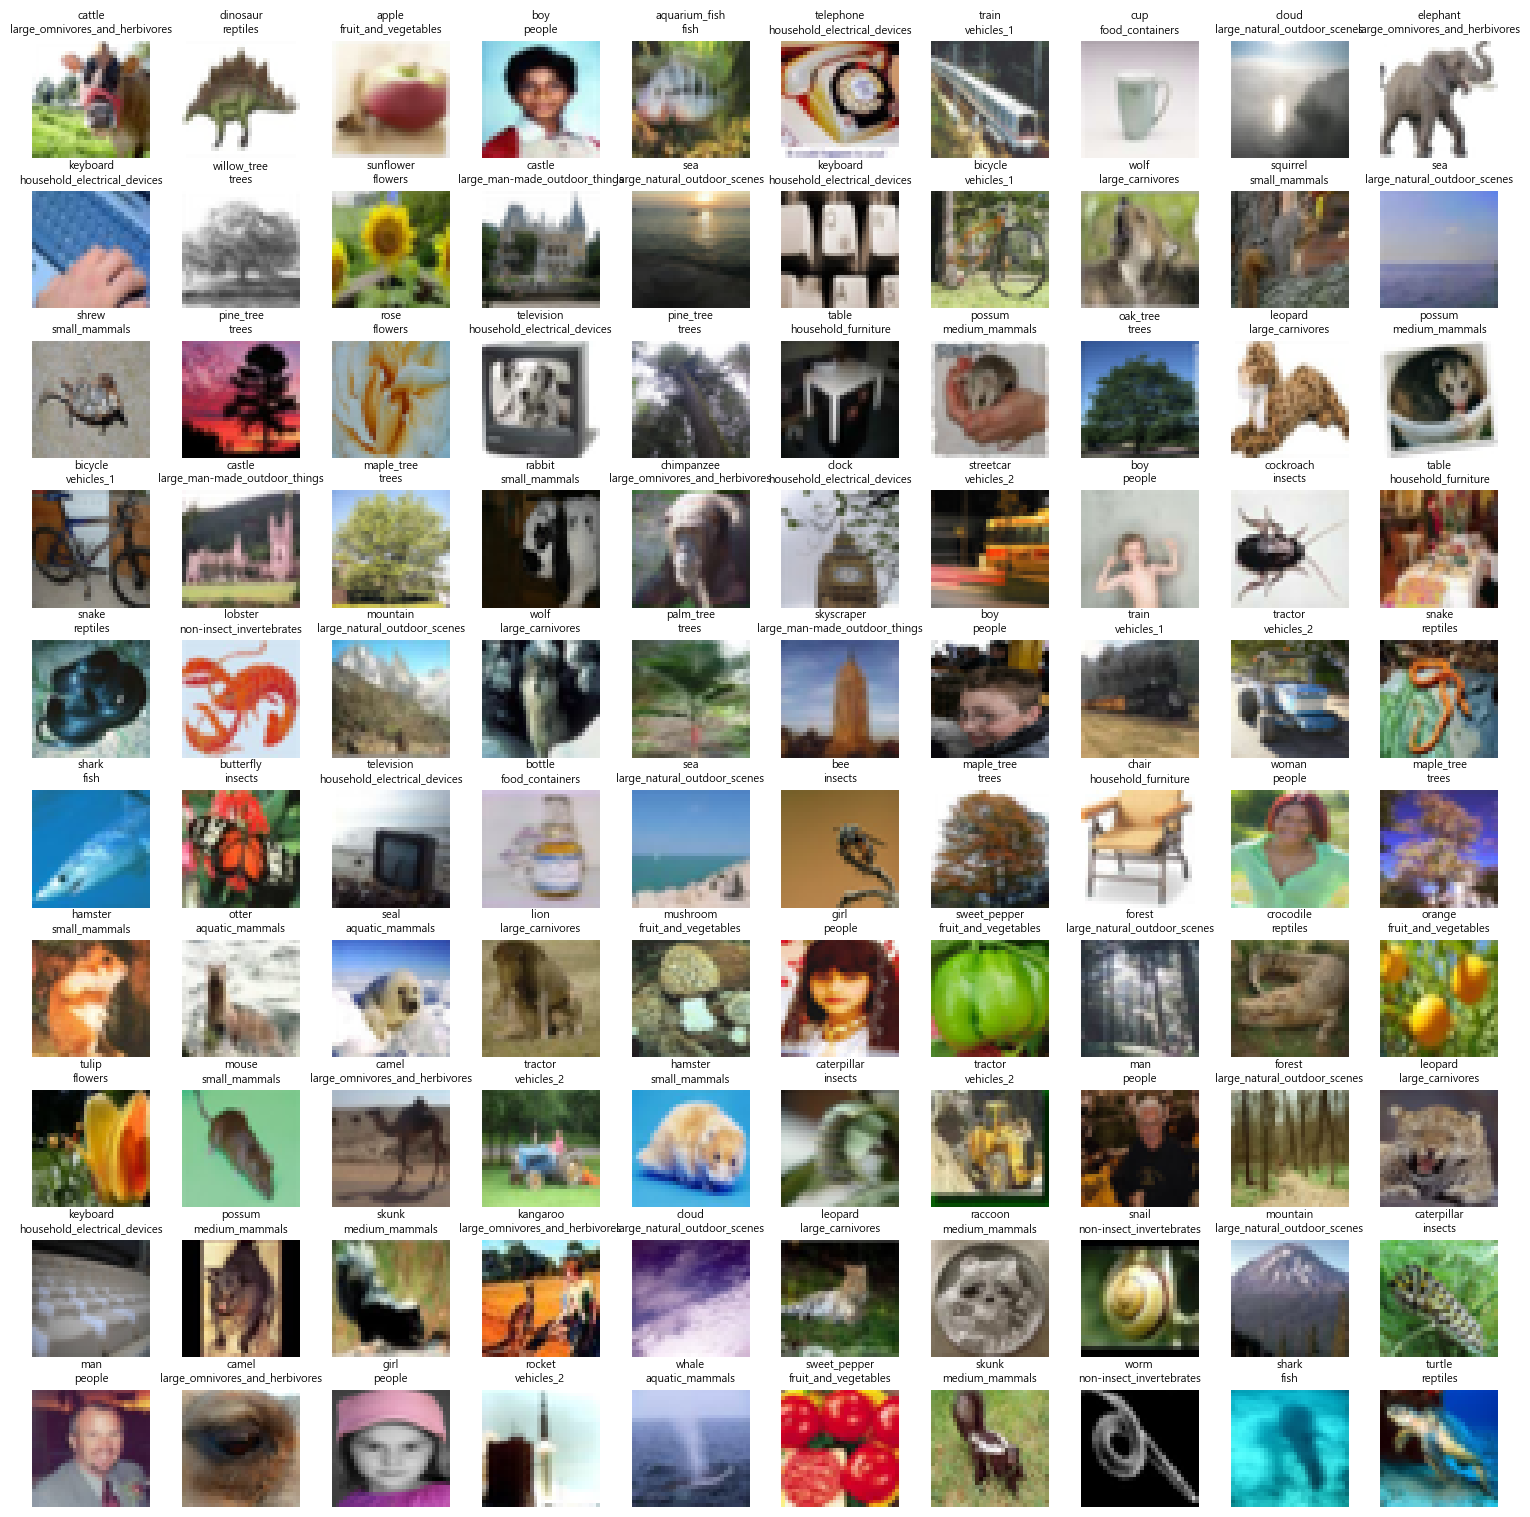

In [7]:
plt.figure(figsize=(15, 15))
for i in range(100):
    img = train_data[b'data'][i]
    img = img.reshape(3, 32, 32).transpose(1, 2, 0)
    img = img / 255.0

    fine_idx = train_data[b'fine_labels'][i]
    coarse_idx = train_data[b'coarse_labels'][i]
    fine_label = fine_label_names[fine_idx]
    coarse_label = coarse_label_names[coarse_idx]

    plt.subplot(10, 10, i + 1)
    plt.imshow(img)
    plt.title(f"{fine_label}\n{coarse_label}", fontsize=8)
    plt.axis('off')
    plt.subplots_adjust(wspace=0.05, hspace=0.05)  # 이미지 간격 최소화

plt.tight_layout(pad=0.1)
plt.show()

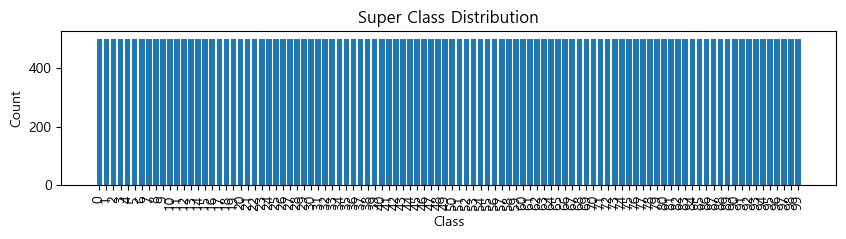

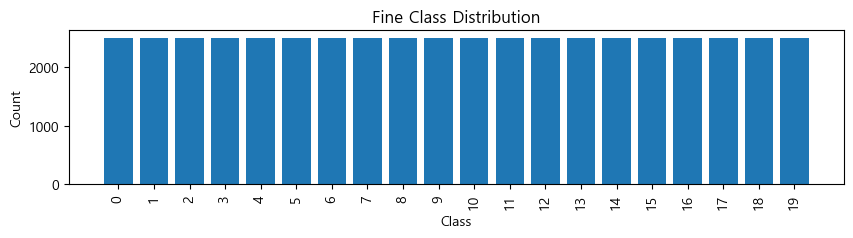

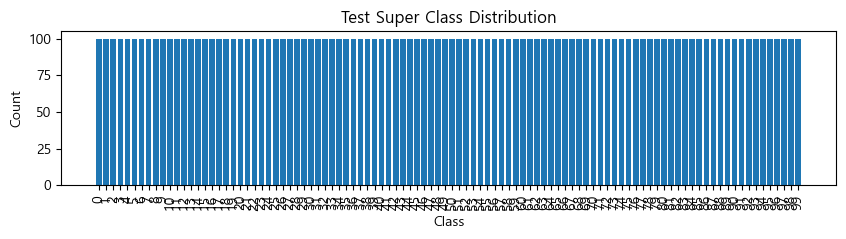

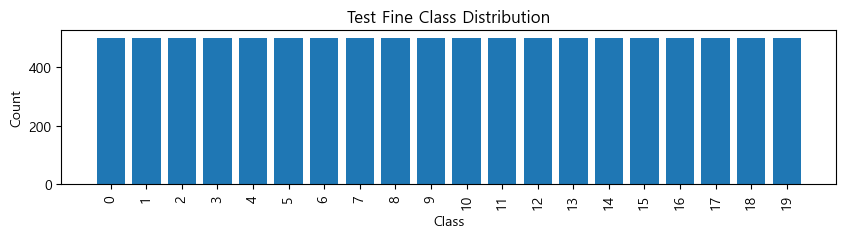

In [8]:
# 클래스 통계
def class_counts(data):
    unique, counts = np.unique(data[b'fine_labels'], return_counts=True)
    superclass_dict = dict(zip(unique, counts))
    unique, counts = np.unique(data[b'coarse_labels'], return_counts=True)
    class_dict = dict(zip(unique, counts))
    return superclass_dict, class_dict
superclass_counts, fineclass_counts = class_counts(train_data)
t_superclass_counts, t_fineclass_counts = class_counts(test_data)

# 클래스 통계 시각화
def plot_class_distribution(class_counts, title):
    plt.figure(figsize=(10, 2))
    plt.bar(class_counts.keys(), class_counts.values())
    plt.xticks(list(class_counts.keys()), rotation=90)
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.title(title)
    plt.show()
plot_class_distribution(superclass_counts, 'Super Class Distribution')
plot_class_distribution(fineclass_counts, 'Fine Class Distribution')
plot_class_distribution(t_superclass_counts, 'Test Super Class Distribution')
plot_class_distribution(t_fineclass_counts, 'Test Fine Class Distribution')

---
### 데이터 전처리

In [9]:
def one_hot_encode_xp(y_indices, num_classes):
    """NumPy 또는 CuPy 배열을 사용하여 원-핫 인코딩을 수행합니다."""
    # y_indices가 스칼라 리스트나 NumPy 배열로 들어올 것을 가정
    # 이를 먼저 xp.array로 변환 (GPU 사용 시 GPU로)
    y_indices_xp = xp.asarray(y_indices, dtype=xp.int32) # CuPy는 정수 인덱싱을 위해 int32 선호
    if y_indices_xp.ndim == 0: # 단일 스칼라 값인 경우
        y_indices_xp = y_indices_xp.reshape(1) # 1차원 배열로 만듦
    
    # eye 함수는 xp (CuPy 또는 NumPy)의 것을 사용
    # CuPy의 eye는 기본적으로 float64를 반환하므로 dtype 명시
    one_hot_vector = xp.eye(num_classes, dtype=xp.float32)[y_indices_xp]
    return one_hot_vector.squeeze() # 불필요한 차원 제거 (단일 샘플 처리 시)

# 1. NumPy로 데이터 준비 (CPU에서 수행)
x_np = train_data[b'data'].reshape(-1, 3, 32, 32).astype(np.float32) / 255.0
t_np = np.array(train_data[b'fine_labels']) # 정수 레이블

x_test_np = test_data[b'data'].reshape(-1, 3, 32, 32).astype(np.float32) / 255.0
y_test_indices_np = np.array(test_data[b'fine_labels']) # 정수 레이블

# 2. Train/Validation 분할 (CPU에서 sklearn 사용)
# stratify를 위해 t_np (정수 레이블) 사용
x_train_np, x_val_np, y_train_indices_np, y_val_indices_np = train_test_split(
    x_np, t_np, test_size=0.2, random_state=42, stratify=t_np
)

# 3. NumPy 데이터를 CuPy로 이동 (xp 사용)
# 이미지 데이터 (x)
x_train = xp.asarray(x_train_np)
x_val = xp.asarray(x_val_np)
x_test = xp.asarray(x_test_np)

# 레이블 데이터 (y) - 원-핫 인코딩 후 CuPy로 이동
# one_hot_encode_xp 함수는 내부적으로 xp.asarray를 사용하므로,
# NumPy 인덱스를 입력으로 전달해도 xp가 CuPy이면 결과는 CuPy 배열이 됨.
y_train = one_hot_encode_xp(y_train_indices_np, 100)
y_val = one_hot_encode_xp(y_val_indices_np, 100)
y_test = one_hot_encode_xp(y_test_indices_np, 100)


print("Data shapes after preprocessing and moving to device (xp):")
print(f"x_train shape: {x_train.shape}, type: {type(x_train)}")
print(f"y_train shape: {y_train.shape}, type: {type(y_train)}")
print(f"x_val shape: {x_val.shape}, type: {type(x_val)}")
print(f"y_val shape: {y_val.shape}, type: {type(y_val)}")
print(f"x_test shape: {x_test.shape}, type: {type(x_test)}")
print(f"y_test shape: {y_test.shape}, type: {type(y_test)}")

# 메모리 정리 (선택적): NumPy 배열 삭제
del x_np, t_np, x_test_np, y_test_indices_np
del x_train_np, x_val_np, y_train_indices_np, y_val_indices_np
if xp == cp: # CuPy 사용 시 GPU 메모리 풀 정리
    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()
    print("Cleared NumPy arrays from CPU and freed GPU memory pool.")
else:
    print("Cleared NumPy arrays from CPU.")

Data shapes after preprocessing and moving to device (xp):
x_train shape: (40000, 3, 32, 32), type: <class 'numpy.ndarray'>
y_train shape: (40000, 100), type: <class 'numpy.ndarray'>
x_val shape: (10000, 3, 32, 32), type: <class 'numpy.ndarray'>
y_val shape: (10000, 100), type: <class 'numpy.ndarray'>
x_test shape: (10000, 3, 32, 32), type: <class 'numpy.ndarray'>
y_test shape: (10000, 100), type: <class 'numpy.ndarray'>
Cleared NumPy arrays from CPU.


---
### 모델 정의 및 학습

In [10]:
def flip_xp(img, _):  # 좌우 반전
    return xp.flip(img, axis=2)

def cutout_xp(img, size):  # 패치 제거
    _, h, w = img.shape
    # xp.random.randint 사용
    y, x = xp.random.randint(0, h), xp.random.randint(0, w) 
    y1, y2 = max(0, y - size // 2), min(h, y + size // 2)
    x1, x2 = max(0, x - size // 2), min(w, x + size // 2)
    img_copy = img.copy() # 원본 수정을 피하기 위해 복사본 사용
    img_copy[:, y1:y2, x1:x2] = 0
    return img_copy

def brightness_xp(img, mag):
    # xp.random.rand 사용
    scale = 1 + mag * (xp.random.rand() * 2 - 1)
    return xp.clip(img * scale, 0, 1) # xp.clip 사용

def contrast_xp(img, mag):
    # xp.mean 사용
    mean = xp.mean(img, axis=(1, 2), keepdims=True)
    # xp.random.rand 사용
    scale = 1 + mag * (xp.random.rand() * 2 - 1)
    return xp.clip((img - mean) * scale + mean, 0, 1) # xp.clip 사용

def crop_xp(img, pad):
    C, H, W = img.shape
    # xp.pad 사용
    padded = xp.pad(img, ((0, 0), (pad, pad), (pad, pad)), mode='reflect')
    # xp.random.randint 사용
    top = xp.random.randint(0, 2 * pad)
    left = xp.random.randint(0, 2 * pad)
    return padded[:, top:top + H, left:left + W]

# 연산 및 강도 매핑 (함수명 변경)
AUGMENT_FN_XP = {
    'flip': flip_xp,
    'cutout': cutout_xp,
    'brightness': brightness_xp,
    'contrast': contrast_xp,
    'crop': crop_xp,
}

AUGMENT_MAG_XP = { # 내용은 동일하게 유지
    'flip': None,
    'cutout': lambda m: int(32 * (m / 10)), # size는 정수여야 함
    'brightness': lambda m: 0.9 * (m / 10),
    'contrast': lambda m: 0.9 * (m / 10),
    'crop': lambda m: int(8 * (m / 10)), # pad는 정수여야 함
}

# RandAugment 적용 (이미지 1장, xp 기반)
def apply_randaugment_xp(img, N=2, M=9):
    # img가 CuPy 배열일 경우, 연산 결과도 CuPy 배열
    ops = list(AUGMENT_FN_XP.keys())
    # xp.random.choice 사용
    # CuPy의 choice는 NumPy와 다르게 배열을 직접 받지 않고, 정수 인덱스를 받음
    # chosen_indices = xp.random.choice(len(ops), size=N, replace=False)
    # chosen_ops = [ops[i] for i in chosen_indices]
    # NumPy와 호환성을 위해 np.random.choice를 사용하고 결과를 xp.asarray로 변환하거나,
    # ops 리스트를 xp.array로 변환 후 xp.random.choice를 사용하는 방법 고려.
    # 여기서는 ops가 작은 리스트이므로 np.random.choice를 사용하고, 함수 내에서 xp 연산을 하도록 함.
    # 또는, ops를 xp.array로 변환
    
    # 간단하게는 np.random.choice를 유지하고, 각 함수가 xp 배열을 잘 처리하도록 함
    # chosen_op_names = np.random.choice(ops, size=N, replace=False)

    # xp.random.choice를 사용하려면 ops를 xp.array로 만들거나 인덱스를 사용해야 함.
    # NumPy의 random.choice를 사용하고, 함수 내부에서 xp를 사용하도록 하는 것이 더 간단할 수 있음.
    # 여기서는 NumPy의 choice를 사용하고, 함수들이 xp 배열을 입력받도록 수정했으므로 문제 없음.
    chosen_op_names = np.random.choice(ops, size=N, replace=False)


    temp_img = img # 입력 img가 xp 배열이라고 가정
    for op_name in chosen_op_names:
        fn = AUGMENT_FN_XP[op_name]
        mag_fn = AUGMENT_MAG_XP[op_name]
        mag = mag_fn(M) if mag_fn else None
        temp_img = fn(temp_img, mag) # 각 증강 함수는 xp 배열을 반환
    return temp_img

# 배치 단위 RandAugment (xp 기반)
def randaugment_batch_xp(x_batch, N=2, M=9):
    # x_batch가 CuPy 배열이면, new_batch도 CuPy 배열
    # new_batch = xp.empty_like(x_batch) # xp.empty_like 사용
    # for i in range(x_batch.shape[0]):
    #     new_batch[i] = apply_randaugment_xp(x_batch[i], N, M)
    
    # 더 효율적인 방법: 리스트 컴프리헨션 후 xp.stack 또는 xp.asarray
    augmented_images = [apply_randaugment_xp(x_batch[i], N, M) for i in range(x_batch.shape[0])]
    if augmented_images: # 리스트가 비어있지 않은 경우
        return xp.stack(augmented_images) if isinstance(augmented_images[0], xp.ndarray) else xp.asarray(augmented_images)
    return x_batch # 비어있는 경우 원본 반환 (이런 경우는 거의 없음)


In [11]:
def cutmix_batch_xp(x_batch, t_batch, alpha=1.0):
    """CutMix 증강 (배치 기준, xp 기반)"""
    # x_batch, t_batch가 CuPy 배열이면, 연산 결과도 CuPy 배열
    N, C, H, W = x_batch.shape
    
    # xp.random.permutation 사용
    indices = xp.random.permutation(N)
    x1, x2 = x_batch, x_batch[indices]
    y1, y2 = t_batch, t_batch[indices]

    # xp.random.beta 사용 (CuPy에 beta가 없다면 np 사용 후 asarray)
    # 최신 CuPy는 cupy.random.beta 지원
    lam = xp.random.beta(alpha, alpha) 
    
    # xp.random.randint 사용
    rx = xp.random.randint(0, W)
    ry = xp.random.randint(0, H)
    
    # xp.sqrt 사용
    rw = xp.asarray(W * xp.sqrt(1 - lam), dtype=xp.int32) # 정수형으로 변환
    rh = xp.asarray(H * xp.sqrt(1 - lam), dtype=xp.int32) # 정수형으로 변환

    # xp.clip 사용
    x1_l = xp.clip(rx - rw // 2, 0, W)
    x1_r = xp.clip(rx + rw // 2, 0, W)
    y1_t = xp.clip(ry - rh // 2, 0, H)
    y1_b = xp.clip(ry + rh // 2, 0, H)

    x_cutmix = x1.copy() # xp 배열의 copy 사용
    # 슬라이싱 및 할당은 CuPy에서도 NumPy와 유사하게 동작
    # x_cutmix[:, :, y1_t:y1_b, x1_l:x1_r] = x2[:, :, y1_t:y1_b, x1_l:x1_r]
    # 정수 인덱싱을 위해 astype(int) 추가 (만약 인덱스가 부동소수점일 경우 대비)
    # y1_t, y1_b, x1_l, x1_r은 이미 clip을 통해 정수 범위 내 스칼라 또는 배열일 수 있음.
    # 만약 lam이 스칼라가 아니라 배열이면, rx,ry,rw,rh 등도 배열이 될 수 있음.
    # 현재 코드는 lam이 스칼라로 가정하고 진행. 만약 lam이 배열이면 배치별 다른 cutmix 적용 가능.
    # 여기서는 lam이 스칼라라고 가정하고, 인덱스도 스칼라로 처리.
    
    # 만약 lam이 스칼라이고, rx, ry, rw, rh가 스칼라이면 아래와 같이 직접 사용 가능
    # y1_t, y1_b, x1_l, x1_r은 스칼라가 됨
    # x_cutmix[:, :, int(y1_t):int(y1_b), int(x1_l):int(x1_r)] = x2[:, :, int(y1_t):int(y1_b), int(x1_l):int(x1_r)]
    
    # xp.clip의 결과는 입력과 동일한 타입. 인덱스로 사용하려면 정수여야 함.
    # 만약 rx, ry 등이 스칼라이면 y1_t 등도 스칼라.
    # 배치 전체에 동일한 bounding box를 적용하는 현재 로직에서는 스칼라임.
    # (N, C, H, W) 형태의 x_batch에 대해, 각 이미지마다 다른 cutmix를 하려면 lam, rx, ry 등을 (N,) 형태로 만들어야 함.
    # 현재 코드는 모든 배치 이미지에 동일한 lam, 동일한 박스 크기 및 위치를 적용.
    
    # 스칼라 인덱스로 가정하고 int 변환 추가 (안전을 위해)
    bbx1, bby1, bbx2, bby2 = int(x1_l), int(y1_t), int(x1_r), int(y1_b)
    x_cutmix[:, :, bby1:bby2, bbx1:bbx2] = x2[:, :, bby1:bby2, bbx1:bbx2]


    # lam_adj 계산 시 형변환 주의
    lam_adj = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (H * W))
    t_cutmix = lam_adj * y1 + (1 - lam_adj) * y2

    return x_cutmix, t_cutmix


In [12]:
class BasicBlock:
    """
    ResNet의 BasicBlock (xp 기반)
    """
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, dropout_rate=0.0, weight_init_std='he'):
        self.params = OrderedDict()
        self.layers = OrderedDict()
        self.shortcut_layers = OrderedDict()
        self.grads = OrderedDict()

        # 파라미터 초기화 시 xp 사용
        # Conv1
        self.params['C1_W'] = self._get_init_weight(in_channels * 3 * 3, weight_init_std) * xp.random.randn(out_channels, in_channels, 3, 3).astype(xp.float32)
        self.params['C1_b'] = xp.zeros(out_channels, dtype=xp.float32)
        # BN1
        self.params['BN1_gamma'] = xp.ones(out_channels, dtype=xp.float32)
        self.params['BN1_beta'] = xp.zeros(out_channels, dtype=xp.float32)
        # Conv2
        self.params['C2_W'] = self._get_init_weight(out_channels * 3 * 3, weight_init_std) * xp.random.randn(out_channels, out_channels, 3, 3).astype(xp.float32)
        self.params['C2_b'] = xp.zeros(out_channels, dtype=xp.float32)
        # BN2
        self.params['BN2_gamma'] = xp.ones(out_channels, dtype=xp.float32)
        self.params['BN2_beta'] = xp.zeros(out_channels, dtype=xp.float32)

        shortcut_required = (stride != 1 or in_channels != self.expansion * out_channels)
        if shortcut_required:
            s_out_c = self.expansion * out_channels
            self.params['SC_W'] = self._get_init_weight(in_channels * 1 * 1, weight_init_std) * xp.random.randn(s_out_c, in_channels, 1, 1).astype(xp.float32)
            self.params['SC_b'] = xp.zeros(s_out_c, dtype=xp.float32)
            self.params['SBN_gamma'] = xp.ones(s_out_c, dtype=xp.float32)
            self.params['SBN_beta'] = xp.zeros(s_out_c, dtype=xp.float32)

        # 레이어 생성 (파라미터는 xp 배열로 전달됨)
        self.layers['C1'] = Convolution(self.params['C1_W'], self.params['C1_b'], stride=stride, pad=1)
        self.layers['BN1'] = BatchNorm2d(self.params['BN1_gamma'], self.params['BN1_beta']) # running_mean/var는 내부에서 xp로 초기화
        self.layers['R1'] = Relu()
        if dropout_rate > 0:
            self.layers['Drop1'] = Dropout(dropout_rate)
        self.layers['C2'] = Convolution(self.params['C2_W'], self.params['C2_b'], stride=1, pad=1)
        self.layers['BN2'] = BatchNorm2d(self.params['BN2_gamma'], self.params['BN2_beta'])

        if shortcut_required:
            self.shortcut_layers['SC'] = Convolution(self.params['SC_W'], self.params['SC_b'], stride=stride, pad=0)
            self.shortcut_layers['SBN'] = BatchNorm2d(self.params['SBN_gamma'], self.params['SBN_beta'])
        self.layers['R2'] = Relu()

    def _get_init_weight(self, prev_node_num, weight_init_std):
        # 이 함수는 스케일 팩터(Python float)만 반환하므로 xp 변경 불필요
        if weight_init_std == 'relu' or weight_init_std == 'he':
            return np.sqrt(2.0 / prev_node_num) # np.sqrt는 스칼라에 대해 사용 가능
        elif isinstance(weight_init_std, (int, float)):
            return weight_init_std
        return 0.01

    def forward(self, x, train_flg=True):
        identity = x 

        if self.shortcut_layers:
            s_out = identity
            for layer_name, layer in self.shortcut_layers.items():
                if isinstance(layer, (BatchNorm2d, Dropout)):
                    s_out = layer.forward(s_out, train_flg)
                else:
                    s_out = layer.forward(s_out)
            identity = s_out
        
        out = self.layers['C1'].forward(x)
        out = self.layers['BN1'].forward(out, train_flg)
        out = self.layers['R1'].forward(out)

        if 'Drop1' in self.layers:
            out = self.layers['Drop1'].forward(out, train_flg)

        out = self.layers['C2'].forward(out)
        out = self.layers['BN2'].forward(out, train_flg)
        out += identity
        out = self.layers['R2'].forward(out)
        return out

    def backward(self, dout):
        dout = self.layers['R2'].backward(dout)
        didentity = dout.copy()
        dmain = dout.copy()

        dmain = self.layers['BN2'].backward(dmain)
        self.grads['BN2_gamma'] = self.layers['BN2'].dgamma
        self.grads['BN2_beta'] = self.layers['BN2'].dbeta
        
        dmain = self.layers['C2'].backward(dmain)
        self.grads['C2_W'] = self.layers['C2'].dW
        self.grads['C2_b'] = self.layers['C2'].db

        if 'Drop1' in self.layers:
            dmain = self.layers['Drop1'].backward(dmain)
        
        dmain = self.layers['R1'].backward(dmain)
        
        dmain = self.layers['BN1'].backward(dmain)
        self.grads['BN1_gamma'] = self.layers['BN1'].dgamma
        self.grads['BN1_beta'] = self.layers['BN1'].dbeta

        dmain = self.layers['C1'].backward(dmain)
        self.grads['C1_W'] = self.layers['C1'].dW
        self.grads['C1_b'] = self.layers['C1'].db

        if self.shortcut_layers:
            shortcut_layers_reversed = list(self.shortcut_layers.items())
            shortcut_layers_reversed.reverse()
            for layer_name, layer in shortcut_layers_reversed:
                didentity = layer.backward(didentity)
                if isinstance(layer, Convolution):
                    self.grads[f'{layer_name}_W'] = layer.dW
                    self.grads[f'{layer_name}_b'] = layer.db
                elif isinstance(layer, BatchNorm2d):
                    self.grads[f'{layer_name}_gamma'] = layer.dgamma
                    self.grads[f'{layer_name}_beta'] = layer.dbeta
        
        dx = dmain + didentity
        return dx

In [13]:
class CustomResNet:
    def __init__(self, input_dim=(3, 32, 32), num_classes=100,
                 block_class=BasicBlock, 
                 num_blocks_list=[2, 2, 2, 2],
                 initial_channels=64,
                 channels_list=[64, 128, 256, 512],
                 weight_init_std='he', 
                 dropout_rate_in_block=0.0,
                 fc_dropout_ratio=0.0,
                 verbose=False):

        self.verbose = verbose
        self.params = OrderedDict()
        self.layers = OrderedDict()
        self.grads = OrderedDict()
        self.weight_init_std = weight_init_std
        self.num_classes = num_classes

        input_c, input_h, input_w = input_dim
        current_channels = input_c

        if self.verbose: print(f"Input: {input_dim}")

        # 1. Initial Convolution (Conv1 -> BN1 -> ReLU1) - xp 사용
        C1_fn = initial_channels
        # self.params['C1_W'] = self._get_init_weight(current_channels * 3 * 3) * np.random.randn(C1_fn, current_channels, 3, 3) # 이전 코드
        self.params['C1_W'] = self._get_init_weight(current_channels * 3 * 3) * xp.random.randn(C1_fn, current_channels, 3, 3).astype(xp.float32)
        self.params['C1_b'] = xp.zeros(C1_fn, dtype=xp.float32)
        self.layers['C1'] = Convolution(self.params['C1_W'], self.params['C1_b'], stride=1, pad=1)
        current_channels = C1_fn

        # self.params['BN1_gamma'] = np.ones(current_channels); self.params['BN1_beta'] = np.zeros(current_channels, dtype=np.float32) # 이전 코드
        self.params['BN1_gamma'] = xp.ones(current_channels, dtype=xp.float32)
        self.params['BN1_beta'] = xp.zeros(current_channels, dtype=xp.float32)
        self.layers['BN1'] = BatchNorm2d(self.params['BN1_gamma'], self.params['BN1_beta']) # BN 내부에서 running_mean/var는 xp로 초기화
        self.layers['R1'] = Relu()
        if self.verbose: print(f"After Conv1: channels={current_channels}")

        # 2. Residual Stages - _make_stage 내부에서 BasicBlock이 xp 파라미터 사용
        for i, (num_blocks, stage_out_channels) in enumerate(zip(num_blocks_list, channels_list)):
            stage_name = f'S{i+1}'
            stride_first = 1 if i == 0 else 2
            self._make_stage(block_class, stage_name, current_channels, stage_out_channels,
                             num_blocks, stride_first, dropout_rate_in_block, weight_init_std)
            current_channels = stage_out_channels * block_class.expansion
            if self.verbose: print(f"After {stage_name}: channels={current_channels}")

        # 3. Global Average Pooling
        self.layers['GAP'] = GlobalAveragePooling()
        if self.verbose: print(f"After GAP: features={current_channels}")

        # 4. Optional Dropout before FC
        if fc_dropout_ratio > 0:
            self.layers['Drop_FC'] = Dropout(fc_dropout_ratio)

        # 5. Fully Connected Layer (Classifier) - xp 사용
        fc_input_size = current_channels
        # self.params['FC_W'] = self._get_init_weight(fc_input_size) * np.random.randn(fc_input_size, num_classes) # 이전 코드
        self.params['FC_W'] = self._get_init_weight(fc_input_size) * xp.random.randn(fc_input_size, num_classes).astype(xp.float32)
        self.params['FC_b'] = xp.zeros(num_classes, dtype=xp.float32)
        self.layers['FC'] = Affine(self.params['FC_W'], self.params['FC_b'])
        if self.verbose: print(f"FC Layer: {fc_input_size} -> {num_classes}")

        self.last_layer = SoftmaxWithLoss() # 내부적으로 xp 사용
        if self.verbose: print("CustomResNet initialized.")

    def _get_init_weight(self, prev_node_num):
        # 스케일 팩터(Python float) 반환, xp 변경 불필요
        if self.weight_init_std == 'relu' or self.weight_init_std == 'he':
            return np.sqrt(2.0 / prev_node_num)
        elif isinstance(self.weight_init_std, (int, float)):
            return self.weight_init_std
        return 0.01

    def _make_stage(self, block_class, stage_prefix, in_c, out_c_block, num_blocks, stride_first, dr, wis):
        current_block_in_c = in_c
        b0_name = f'{stage_prefix}_B0'
        # block_class (BasicBlock) 생성자에서 파라미터를 xp 배열로 초기화
        block0 = block_class(current_block_in_c, out_c_block, stride_first, dr, wis)
        self.layers[b0_name] = block0
        for p_name, p_val in block0.params.items(): self.params[f'{b0_name}_{p_name}'] = p_val
        current_block_in_c = out_c_block * block_class.expansion

        for i in range(1, num_blocks):
            bi_name = f'{stage_prefix}_B{i}'
            block_i = block_class(current_block_in_c, out_c_block, 1, dr, wis)
            self.layers[bi_name] = block_i
            for p_name, p_val in block_i.params.items(): self.params[f'{bi_name}_{p_name}'] = p_val

    def predict(self, x, train_flg=True):
        if self.verbose: print(f"Predict input: {x.shape}, type: {type(x)}")
        for name, layer in self.layers.items():
            if self.verbose: prev_x_shape = x.shape
            if isinstance(layer, (BasicBlock, BatchNorm2d, Dropout)):
                x = layer.forward(x, train_flg)
            elif isinstance(layer, GlobalAveragePooling):
                x = layer.forward(x)
                # GAP의 출력은 (N,C). Affine 계층은 (N, D) 형태를 기대하므로 reshape 불필요.
                # if x.ndim == 4 and x.shape[2] == 1 and x.shape[3] == 1: x = x.reshape(x.shape[0], -1) 
            else: # Convolution, Relu, Affine
                x = layer.forward(x)
            if self.verbose: print(f"  Layer {name} ({type(layer).__name__}): {prev_x_shape} -> {x.shape}, type: {type(x)}")
        return x

    def loss(self, x, t, train_flg=True):
        y = self.predict(x, train_flg)
        loss_val = self.last_layer.forward(y, t)
        # loss_val이 xp 배열(스칼라)일 수 있으므로 Python float으로 변환 (history 저장용)
        return loss_val # Trainer에서 .get() 또는 cp.asnumpy() 처리

    def accuracy(self, x, t, train_flg=False):
        y = self.predict(x, train_flg) # y는 xp 배열
        y_pred = xp.argmax(y, axis=1)
        
        # t가 원-핫 벡터일 경우 argmax, 아니면 그대로 사용
        if t.ndim != 1 and t.shape[1] > 1: # 원-핫 벡터로 간주 (예: (N, 100))
             t_labels = xp.argmax(t, axis=1)
        else: # 이미 레이블 인덱스 배열 (예: (N,))
             t_labels = t
        
        # 정확도 계산 (xp 배열로)
        acc = xp.sum(y_pred == t_labels) / float(x.shape[0])
        # 결과를 Python float으로 변환 (history 저장 및 출력용)
        if xp == cp:
            return acc.get()
        else: # NumPy
            return float(acc)


    def gradient(self, x, t):
        self.loss(x, t, train_flg=True) 
        dout = self.last_layer.backward(1)

        layers_reversed = list(self.layers.items())
        layers_reversed.reverse()
        self.grads = OrderedDict() 

        for name, layer_instance in layers_reversed:
            if self.verbose: print(f"Backwarding: {name}")
            dout = layer_instance.backward(dout)
            
            if isinstance(layer_instance, BasicBlock):
                for block_grad_key, block_grad_val in layer_instance.grads.items():
                    self.grads[f'{name}_{block_grad_key}'] = block_grad_val
            elif isinstance(layer_instance, Convolution):
                self.grads[f'{name}_W'] = layer_instance.dW; self.grads[f'{name}_b'] = layer_instance.db
            elif isinstance(layer_instance, Affine):
                self.grads[f'{name}_W'] = layer_instance.dW; self.grads[f'{name}_b'] = layer_instance.db
            elif isinstance(layer_instance, BatchNorm2d):
                self.grads[f'{name}_gamma'] = layer_instance.dgamma; self.grads[f'{name}_beta'] = layer_instance.dbeta
        return self.grads

    def batch_loss(self, x, t, batch_size=100, label="Loss", train_flg=False):
        loss_sum = 0
        num_samples = 0 # num_batches 대신 num_samples로 명칭 변경 (실제 샘플 수 기반 평균)
        num_iterations = (x.shape[0] + batch_size - 1) // batch_size # 올림 처리

        for i in tqdm(range(num_iterations), desc=label, leave=False):
            start = i * batch_size
            end = min((i + 1) * batch_size, x.shape[0])
            x_batch = x[start:end]
            t_batch = t[start:end]
            
            current_loss = self.loss(x_batch, t_batch, train_flg=train_flg) # xp 스칼라 배열 반환
            if xp == cp:
                current_loss = current_loss.get() # Python float으로 변환
            else:
                current_loss = float(current_loss)

            loss_sum += current_loss * x_batch.shape[0] # 각 배치의 손실 * 배치 크기
            num_samples += x_batch.shape[0]
        return loss_sum / num_samples if num_samples > 0 else 0

    def batch_accuracy(self, x, t, batch_size=100, label="Acc", train_flg=False):
        acc_sum = 0
        num_samples = 0
        num_iterations = (x.shape[0] + batch_size - 1) // batch_size

        for i in tqdm(range(num_iterations), desc=label, leave=False):
            start = i * batch_size
            end = min((i + 1) * batch_size, x.shape[0])
            x_batch = x[start:end]
            t_batch = t[start:end]
            
            # accuracy 함수는 이미 Python float을 반환하도록 수정됨
            current_acc = self.accuracy(x_batch, t_batch, train_flg=train_flg) 
            acc_sum += current_acc * x_batch.shape[0] # 각 배치의 정확도 * 배치 크기
            num_samples += x_batch.shape[0]
        return acc_sum / num_samples if num_samples > 0 else 0


In [14]:
class CustomTrainer:
    def __init__(self, network, 
                 x_train, t_train, x_val, t_val, x_test, t_test,
                 epochs=20, mini_batch_size=100,
                 optimizer='Adam', optimizer_param={'lr':0.001}, 
                 verbose=True, model_save_path='best_model.pkl',
                 weight_decay_lambda=0.0,
                 use_augmentation=True,
                 scheduler_class=None, # 스케줄러 클래스 추가
                 scheduler_param={}    # 스케줄러 파라미터 추가
                 ):
        
        self.network = network
        self.x_train = x_train
        self.t_train = t_train
        self.x_val = x_val
        self.t_val = t_val
        self.x_test = x_test
        self.t_test = t_test
        
        self.epochs = epochs
        self.batch_size = mini_batch_size
        self.verbose = verbose
        self.model_save_path = model_save_path
        self.weight_decay_lambda = weight_decay_lambda
        self.use_augmentation = use_augmentation
        
        optimizer_class_dict = {'sgd':SGD, 'momentum':Momentum, 'nesterov':Nesterov,
                                'adagrad':AdaGrad, 'rmsprop':RMSprop, 'adam':Adam}
        self.optimizer = optimizer_class_dict[optimizer.lower()](**optimizer_param)
        
        self.scheduler = None
        if scheduler_class:
            # ReduceLROnPlateau는 optimizer 객체를 직접 받음
            self.scheduler = scheduler_class(self.optimizer, **scheduler_param)

        self.current_x_train = self.x_train
        self.current_t_train = self.t_train
        self.train_size = self.current_x_train.shape[0]
        self.iter_per_epoch = max(self.train_size // self.batch_size, 1)
        
        self.best_val_loss = float('inf')
        self.history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []} # lr 기록 추가

    def _train_step(self):
        # ...existing code...
        permutation = xp.random.permutation(self.train_size)
        batch_indices = permutation[:self.batch_size]
        
        x_batch = self.current_x_train[batch_indices]
        t_batch = self.current_t_train[batch_indices]
        
        if self.use_augmentation:
            x_batch = randaugment_batch_xp(x_batch, N=2, M=9) 
            x_batch, t_batch = cutmix_batch_xp(x_batch, t_batch, alpha=1.0)

        grads = self.network.gradient(x_batch, t_batch)

        if self.weight_decay_lambda > 0:
            for key in self.network.params.keys():
                if key.endswith('_W'): 
                    grads[key] += self.weight_decay_lambda * self.network.params[key]
        
        self.optimizer.update(self.network.params, grads)
    
    def train(self):
        for epoch in range(1, self.epochs + 1):
            # ... (기존 tqdm 루프) ...
            with tqdm(range(self.iter_per_epoch), desc=f"Epoch {epoch}/{self.epochs}", unit="batch", mininterval=1) as pbar:
                for _ in pbar:
                    self._train_step()

            current_train_loss = self.network.batch_loss(self.current_x_train, self.current_t_train, self.batch_size, "Train Loss", train_flg=False)
            current_train_acc = self.network.batch_accuracy(self.current_x_train, self.current_t_train, self.batch_size, "Train Acc", train_flg=False)
            current_val_loss = self.network.batch_loss(self.x_val, self.t_val, self.batch_size, "Val Loss", train_flg=False)
            current_val_acc = self.network.batch_accuracy(self.x_val, self.t_val, self.batch_size, "Val Acc", train_flg=False)

            self.history['train_loss'].append(current_train_loss)
            self.history['train_acc'].append(current_train_acc)
            self.history['val_loss'].append(current_val_loss)
            self.history['val_acc'].append(current_val_acc)
            current_lr = self.optimizer.lr # 현재 학습률 기록
            self.history['lr'].append(current_lr)


            if self.verbose:
                print(f"  - Train Loss: {current_train_loss:.4f}, Train Acc: {current_train_acc:.4f} | "
                      f"Val Loss: {current_val_loss:.4f}, Val Acc: {current_val_acc:.4f} | LR: {current_lr:.1e}")

            if self.scheduler:
                self.scheduler.step(current_val_loss, epoch) # 스케줄러 업데이트

            if current_val_loss < self.best_val_loss:
                # ... (기존 모델 저장 로직) ...
                self.best_val_loss = current_val_loss
                try:
                    network_to_save = self.network
                    if xp == cp:
                        pass 
                    
                    with open(self.model_save_path, 'wb') as f:
                        pickle.dump(network_to_save, f)
                    if self.verbose:
                        print(f"  -> Best model saved to {self.model_save_path} (Val Loss: {self.best_val_loss:.4f})", flush=True)
                except Exception as e:
                    print(f"  -> Model save failed: {e}")
        
        # ... (기존 최종 테스트 평가 로직) ...
        if self.verbose: print("\n=============== Final Test Evaluation ===============")
        try:
            if self.verbose: print(f"Loading best model from {self.model_save_path}...")
            with open(self.model_save_path, 'rb') as f:
                self.network = pickle.load(f) 
            
            test_loss = self.network.batch_loss(self.x_test, self.t_test, self.batch_size, "Test Loss", train_flg=False)
            test_acc = self.network.batch_accuracy(self.x_test, self.t_test, self.batch_size, "Test Acc", train_flg=False)
            
            if self.verbose:
                print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")
        except FileNotFoundError:
            print(f"Error: Model file not found at {self.model_save_path}. Skipping final test evaluation.")
        except Exception as e:
            print(f"Error loading or evaluating model: {e}")
            
        return self.history

In [15]:
def write_param_note(model_path, time_date, model_note, model_settings=None, trainer_settings=None):
    param_notes = f"time_date: {time_date}\n"

    param_notes += "모델 세팅 :\n"
    for key, value in model_settings.items():
        param_notes += f"    {key}: {value}\n"

    param_notes += "트레이너 세팅:\n"
    for key, value in trainer_settings.items():
        param_notes += f"    {key}: {value}\n"
    param_notes += f"""모델 노트:
    {model_note}
    """
    file_note = open(model_path+'/model_param.txt', 'w')
    file_note.write(param_notes)
    print(f"모델 세팅 노트 작성 완료: {model_path}/model_param.txt")
    file_note.close()


In [16]:
time_date = 'temp250603_1500_100_resnet14_cupy_ReduceLR' # 시간 및 날짜 정보
model_path = f'./saved_model/model_{time_date}'
os.makedirs(model_path, exist_ok=True)

resnet_model_params = {
    'num_classes': 100,
    'block_class': BasicBlock, # xp 기반 BasicBlock 사용
    'num_blocks_list': [2, 2, 2], 
    'initial_channels': 32,
    'channels_list': [32, 64, 128],
    'weight_init_std': 'he',
    'dropout_rate_in_block': 0.0,
    'fc_dropout_ratio': 0.25,
    'verbose': False 
}
trainer_params={
    'epochs' : 10, 
    'mini_batch_size' : 128,
    'optimizer' : 'Adam',
    'optimizer_param' : {'lr':0.001}, # 초기 학습률
    'weight_decay_lambda': 1e-4,
    'use_augmentation': True,
    'scheduler_class': ReduceLROnPlateau, # 스케줄러 클래스 지정
    'scheduler_param': {                 # 스케줄러 파라미터
        'mode': 'min', 
        'factor': 0.1, 
        'patience': 5, # 예시: 5 에폭 동안 개선 없으면 LR 감소
        'verbose': True,
        'min_lr': 1e-8 # 최소 학습률
    }
}
model_note = "CustomResNet (CuPy) with RandAugment_xp, CutMix_xp, L2, ReduceLROnPlateau."

write_param_note(model_path, time_date, model_note, 
                 model_settings=resnet_model_params,
                 trainer_settings=trainer_params)

network = CustomResNet(**resnet_model_params) 

trainer = CustomTrainer(network, x_train, y_train, x_val, y_val, x_test, y_test,
                  epochs=trainer_params['epochs'],
                  mini_batch_size=trainer_params['mini_batch_size'], 
                  optimizer=trainer_params['optimizer'], 
                  optimizer_param=trainer_params['optimizer_param'],
                  model_save_path=os.path.join(model_path, 'custom_resnet_best_model.pkl'),
                  weight_decay_lambda=trainer_params['weight_decay_lambda'],
                  use_augmentation=trainer_params['use_augmentation'],
                  scheduler_class=trainer_params['scheduler_class'], # 스케줄러 전달
                  scheduler_param=trainer_params['scheduler_param'], # 스케줄러 파라미터 전달
                  verbose=1)

print(f"Starting training with {'CuPy (GPU)' if xp == cp else 'NumPy (CPU)'} and ReduceLROnPlateau scheduler...")
start_time = time()
history = trainer.train()
end_time = time()
print(f"Training finished. Total time: {end_time - start_time:.2f} seconds.")

# history 저장 (pickle) - history 값들은 이미 Python float/int
with open(os.path.join(model_path, 'custom_resnet_history.pkl'), 'wb') as f:
    pickle.dump(history, f)
print(f"History saved to {os.path.join(model_path, 'custom_resnet_history.pkl')}")

# GPU 메모리 정리 (CuPy 사용 시)
if xp == cp:
    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()
    print("CuPy memory pool freed.")

모델 세팅 노트 작성 완료: ./saved_model/model_temp250603_1500_100_resnet14_cupy_ReduceLR/model_param.txt
Starting training with NumPy (CPU) and ReduceLROnPlateau scheduler...


Epoch 1/10:   0%|          | 0/312 [00:00<?, ?batch/s]

Epoch 1/10:   1%|▏         | 4/312 [00:48<1:02:17, 12.14s/batch]


KeyboardInterrupt: 

In [ ]:
# 모델 로드 및 테스트 예시
model_to_load_path = os.path.join(model_path, 'custom_resnet_best_model.pkl')
try:
    with open(model_to_load_path, 'rb') as f:
        loaded_network = pickle.load(f)
    print(f"Model loaded from {model_to_load_path}")
    # 로드된 모델로 테스트 정확도 평가
    test_loss_loaded = loaded_network.batch_loss(x_test, y_test, batch_size=trainer_params['mini_batch_size'], label="Loaded Test Loss")
    test_acc_loaded = loaded_network.batch_accuracy(x_test, y_test, batch_size=trainer_params['mini_batch_size'], label="Loaded Test Acc")
    print(f"Loaded Model -> Test Loss: {test_loss_loaded:.4f}, Test Accuracy: {test_acc_loaded:.4f}")
except FileNotFoundError:
    print(f"Model file not found: {model_to_load_path}")
except Exception as e:
    print(f"Error loading model: {e}")

Model loaded from ./saved_model/model_250530_0340_100_resnet14\custom_resnet_best_model.pkl


Loaded Model -> Test Loss: 1.6789, Test Accuracy: 0.5478


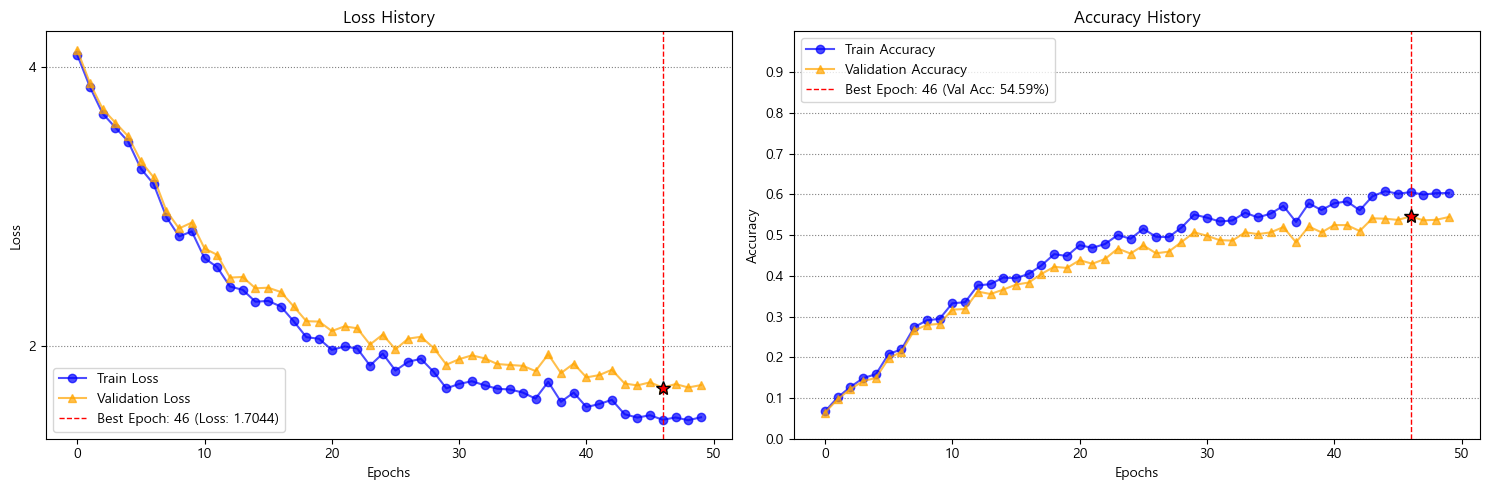

In [ ]:
# History 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Validation Loss가 최소인 epoch 찾기
best_epoch_idx = np.argmin(history['val_loss'])
min_val_loss = history['val_loss'][best_epoch_idx]
val_acc_at_best_loss = history['val_acc'][best_epoch_idx]

# Loss
ax1.plot(history['train_loss'], marker='o', linestyle='-', label='Train Loss', color='blue', alpha=0.7)
ax1.plot(history['val_loss'], marker='^', linestyle='-', label='Validation Loss', color='orange', alpha=0.7)
ax1.set_title('Loss History')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')

# y축 그리드 설정 (2 간격)
y_min_loss, y_max_loss = ax1.get_ylim()
ax1.set_yticks(np.arange(np.floor(y_min_loss / 2) * 2, np.ceil(y_max_loss / 2) * 2 + 2, 2)) # 2 간격으로 눈금 설정
ax1.grid(axis='y', linestyle=':', color='gray')

# 최소 Validation Loss 지점 표시
ax1.axvline(x=best_epoch_idx, color='red', linestyle='--', linewidth=1, label=f'Best Epoch: {best_epoch_idx} (Loss: {min_val_loss:.4f})')
ax1.plot(best_epoch_idx, min_val_loss, marker='*', markersize=10, color='red', linestyle='None', markeredgecolor='black')
ax1.legend()

# Accuracy
ax2.plot(history['train_acc'], marker='o', linestyle='-', label='Train Accuracy', color='blue', alpha=0.7)
ax2.plot(history['val_acc'], marker='^', linestyle='-', label='Validation Accuracy', color='orange', alpha=0.7)
ax2.set_title('Accuracy History')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')

# y축 범위 및 그리드 설정 (0.0 ~ 0.9, 0.1 간격)
ax2.set_ylim(0.0, 1.0)
ax2.set_yticks(np.arange(0.0, 0.91, 0.1)) # 0.1 간격으로 눈금 설정
ax2.grid(axis='y', linestyle=':', color='gray')

# 최소 Validation Loss 지점 (Accuracy 플롯에도 동일 epoch 표시)
ax2.axvline(x=best_epoch_idx, color='red', linestyle='--', linewidth=1, label=f'Best Epoch: {best_epoch_idx} (Val Acc: {val_acc_at_best_loss*100:2.2f}%)')
ax2.plot(best_epoch_idx, val_acc_at_best_loss, marker='*', markersize=10, color='red', linestyle='None', markeredgecolor='black')
ax2.legend()

plt.tight_layout()
plt.show()